In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("../data/analysis_dataset.csv")

print("shape",df.shape)
print("\nFirst rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

print("Basic statistics:")
print(df.describe())

shape (56950, 14)

First rows:
                    datetime   price    load  solar    wind     gas  lignite  \
0  2022-08-01 00:00:00+03:00  428.67  6511.0    0.0   541.0  3922.0   1113.0   
1  2022-08-01 01:00:00+03:00  429.66  6133.0    0.0   588.0  4193.0   1137.0   
2  2022-08-01 02:00:00+03:00  394.93  5801.0    0.0   700.0  3706.0   1144.0   
3  2022-08-01 03:00:00+03:00  351.51  5622.0    0.0   895.0  3360.0   1120.0   
4  2022-08-01 04:00:00+03:00  320.86  5534.0    0.0  1087.0  3180.0   1148.0   

   hydro  net_import_bg  net_import_it  net_import_mk  hour  day_of_week  \
0  509.0          336.0         -509.0          226.0    21            0   
1  294.0          275.0         -509.0           21.0    22            0   
2  280.0          295.0         -509.0           38.0    23            0   
3  172.0          307.0         -509.0           77.0     0            1   
4  171.0          297.0         -509.0           83.0     1            1   

   month  
0      7  
1      7 

In [2]:
import os

os.makedirs("../plots",exist_ok=True)

Price range: €-50.00 to €942.00
Negative price hours: 1573


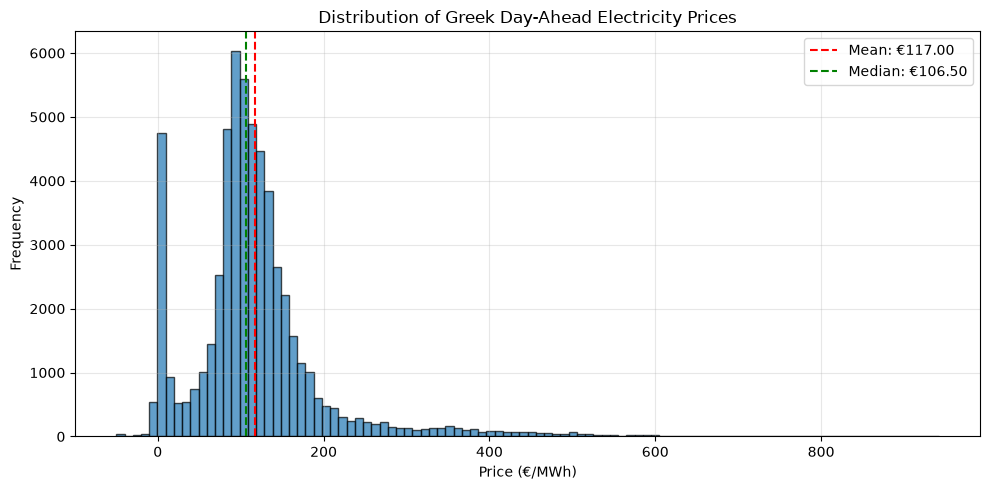

In [3]:
fig,ax=plt.subplots(figsize=(10,5))

ax.hist(df["price"],bins=100,edgecolor="black",alpha=0.7)
ax.set_xlabel("Price (€/MWh)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Greek Day-Ahead Electricity Prices")
ax.axvline(df["price"].mean(),color="red",linestyle="--",label=f"Mean: €{df["price"].mean():.2f}")
ax.axvline(df["price"].median(),color="green",linestyle="--",label=f"Median: €{df["price"].median():.2f}")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/price_distribution.png",dpi=150)
plt.show

print(f"Price range: €{df["price"].min():.2f} to €{df["price"].max():.2f}")
print(f"Negative price hours: {len(df[df["price"]<0])}")


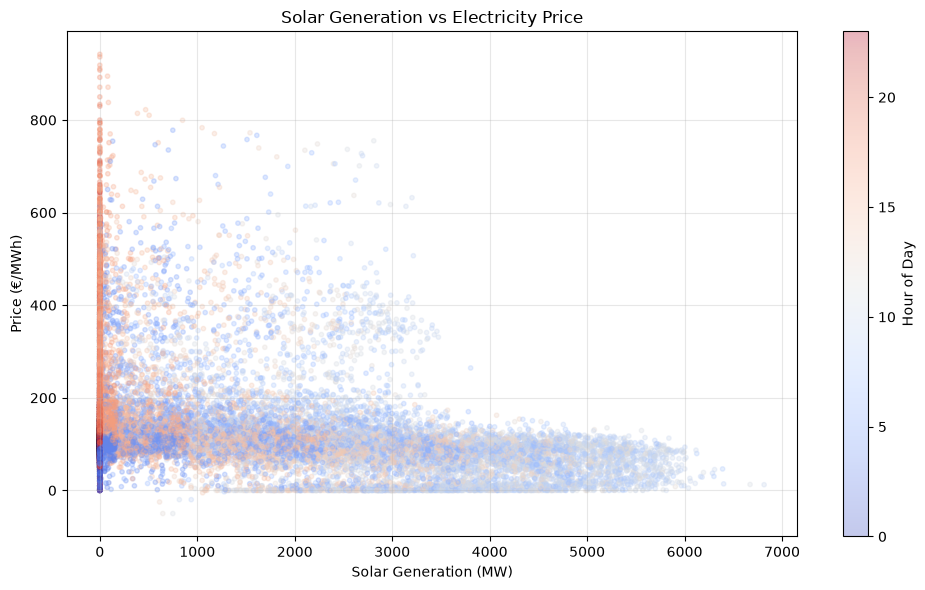

In [4]:
df_clean=df.dropna(subset=["solar","price"])

fig,ax=plt.subplots(figsize=(10,6))
scatter=ax.scatter(df_clean["solar"],df_clean["price"],alpha=0.3,s=10,c=df_clean["hour"],cmap="coolwarm")
ax.set_xlabel("Solar Generation (MW)")
ax.set_ylabel("Price (€/MWh)")
ax.set_title("Solar Generation vs Electricity Price")
ax.grid(alpha=0.3)

cbar=plt.colorbar(scatter,ax=ax)
cbar.set_label("Hour of Day")
plt.tight_layout()
plt.savefig("../plots/solar_vs_price.png",dpi=150)

In [5]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df["hour"] = df["hour"].astype(int)
df["month"] = df["month"].astype(int)
df["day_of_week"] = df["day_of_week"].astype(int)
df["season"] = df["month"].apply(get_season)

print(df["season"].value_counts())

season
Spring    15456
Winter    15144
Summer    13216
Fall      13134
Name: count, dtype: int64


season        Fall      Spring      Summer      Winter
hour                                                  
0       111.099397  103.272671  126.296715  101.219176
1       107.816197  100.976894  123.896243   95.842948
2       108.753035  103.740559  123.711361   93.002250
3       121.258903  110.239596  128.125263   96.324723
4       148.285064  118.824301  133.372377  108.923835


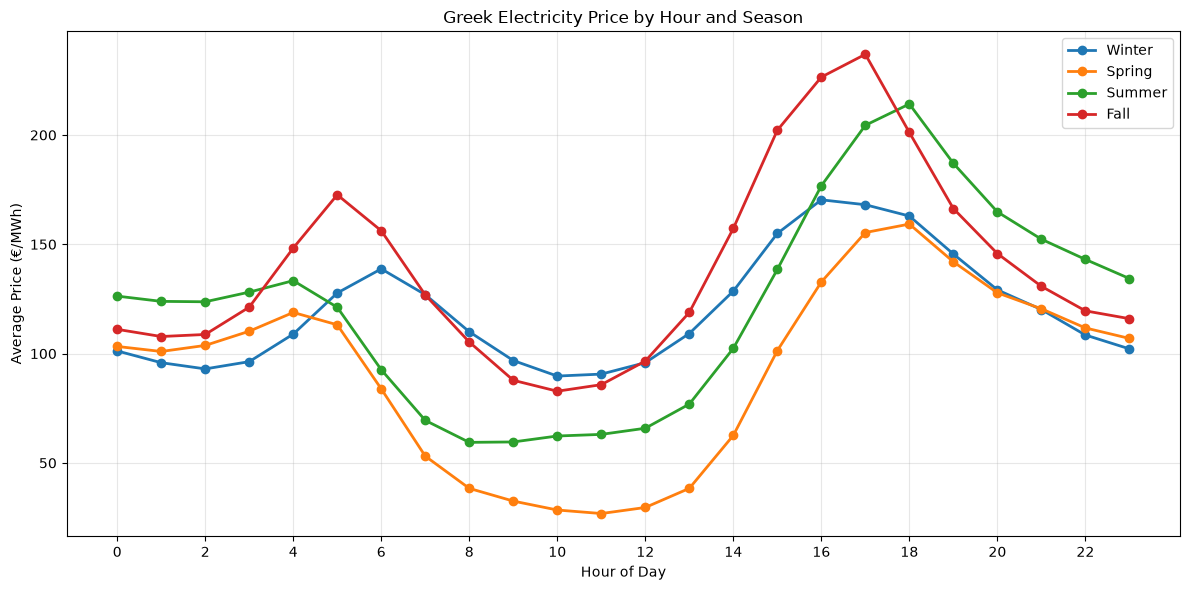

In [6]:
import matplotlib.pyplot as plt

pivot = df.pivot_table(index="hour", columns="season", values="price", aggfunc="mean")

print(pivot.head())

fig, ax = plt.subplots(figsize=(12, 6))
for season in ["Winter", "Spring", "Summer", "Fall"]:
    ax.plot(pivot.index, pivot[season], marker="o", label=season, linewidth=2)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Price (€/MWh)")
ax.set_title("Greek Electricity Price by Hour and Season")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig("../plots/duck_curve.png", dpi=150)
plt.show()

In [7]:
##The biggest peak of prices occures in fall which is concerning trying to find out why

pivot_solar=df.pivot_table(index="hour",columns="season",values="solar",aggfunc="mean")
print(pivot_solar.loc[15:21])

season        Fall      Spring       Summer      Winter
hour                                                   
15      265.087912  903.452899  1459.474638  104.719557
16       22.051282  205.050725   505.981884    2.040590
17       15.974359   14.217391    70.797101    0.586716
18       10.641026    1.365942     0.554348    0.649446
19        0.065934    1.202899     0.000000    0.826568
20        0.000000    0.000000     0.000000    0.000000
21        0.000000    0.000000     0.000000    0.000000


In [8]:


pivot_load = df.pivot_table(index="hour", columns="season", values="load", aggfunc="mean")
print(pivot_load.loc[15:21])

##TURNS OUT ITS NOT BECAUSE OF IT

season         Fall       Spring       Summer       Winter
hour                                                      
15      5596.603022  5110.186141  7296.875000  6243.045706
16      5885.453984  5346.165082  7204.328125  6677.143352
17      5959.997940  5723.076087  7141.999321  6798.882964
18      5715.982143  5755.093071  7136.777853  6713.142659
19      5334.741071  5373.247283  6833.085598  6363.841413
20      4976.353709  4951.988451  6473.061141  5900.976454
21      4635.644628  4562.164402  6080.265753  5442.707064


In [9]:
#TRYING TO FIND OUT IF IT IS BECAUSEOF RESIDUAL LOADS


df["residual_load"] = df["load"] - df["solar"].fillna(0) - df["wind"].fillna(0)
pivot_resid = df.pivot_table(index="hour", columns="season", values="residual_load", aggfunc="mean")
print(pivot_resid.loc[15:21])

##THE RESIDUAL LOAD FOR FALL IS 3D HIGHEST SO HYPOTHESIS WAS WRONG



season         Fall       Spring       Summer       Winter
hour                                                      
15      4498.468407  3593.033967  5396.032609  5221.890582
16      4972.217720  4334.428668  6059.697690  5718.326177
17      5056.596841  4843.619565  6344.477582  5831.032548
18      4818.537088  4885.076766  6399.718071  5740.173130
19      4441.315247  4507.899457  6115.052989  5386.888504
20      4078.567995  4096.809103  5766.118207  4919.948753
21      3726.793388  3708.846467  5376.583562  4461.014543


In [10]:

##NEW HYPOTHESIS:THE 2022 EUROPEAN GAS PRICES HAVE INFLATED THE AVERAGES IN LAST 4 YEARS

df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df["year"] = df["datetime"].dt.year

print(df.pivot_table(index="year", columns="season", values="price", aggfunc="mean").round(1))

##HYPOTHESIS CONFIRMED THE AVERAGE FOR 2022 IS ALMOST 300 WHILE OTHER YEARS IT IS AT 110

season   Fall  Spring  Summer  Winter
year                                 
2022    291.5     NaN   436.7   277.0
2023    106.2   116.2   104.7   149.8
2024    113.0    69.7   121.6    99.4
2025    107.6    92.3    86.4   121.0
2026      NaN    91.0   101.5    94.2


In [11]:
##Solar-Price Relationship over year


yearly_hourly=df[df["year"]>=2023].pivot_table(
    index="hour",columns="year",values="price",aggfunc="mean")
print(yearly_hourly.round(1))

neg_by_year=df[df["price"]<0].groupby("year").size()
print("\nNegative price hours per year:")
print(neg_by_year)

year   2023   2024   2025   2026
hour                            
0     105.9   85.4   92.1  109.5
1     100.7   82.7   90.0  107.6
2      98.6   81.5   90.2  109.2
3     105.7   85.9   96.2  113.1
4     119.5   98.9  111.8  118.4
5     132.5  108.3  127.9  107.5
6     130.5  104.6  113.8   78.0
7     118.7   88.1   88.7   47.6
8     105.5   70.8   70.0   35.3
9      95.0   59.9   55.1   33.7
10     89.4   58.0   51.2   30.6
11     85.3   60.7   55.2   30.4
12     88.6   67.1   65.3   33.5
13    103.8   81.6   83.0   40.1
14    120.9  101.1  114.3   66.5
15    139.3  126.0  151.1  112.9
16    156.4  154.5  170.6  147.3
17    171.9  187.8  178.8  158.7
18    169.1  180.3  169.6  156.9
19    147.8  142.1  142.5  146.0
20    129.5  112.9  123.9  135.8
21    120.9  100.6  111.2  128.9
22    113.6   93.6  100.2  118.5
23    109.1   88.8   95.9  112.7

Negative price hours per year:
year
2022       1
2024      11
2025     177
2026    1384
dtype: int64


In [12]:
solar_by_year = df[df["year"] >= 2023].pivot_table(
    index="hour", columns="year", values="solar", aggfunc="mean")
print(solar_by_year.round(0))

year    2023    2024    2025
hour                        
0        0.0     0.0     0.0
1        0.0     0.0     0.0
2       10.0     0.0     0.0
3       19.0    20.0    42.0
4      150.0   206.0   346.0
5      619.0   856.0  1125.0
6     1415.0  1950.0  2234.0
7     2251.0  3038.0  3233.0
8     2856.0  3779.0  3816.0
9     3182.0  4117.0  4006.0
10    3249.0  4168.0  4078.0
11    3091.0  3987.0  3948.0
12    2708.0  3519.0  3600.0
13    2091.0  2746.0  3071.0
14    1283.0  1709.0  2202.0
15     552.0   745.0  1134.0
16     144.0   196.0   339.0
17      27.0    22.0    46.0
18       9.0     0.0     1.0
19       0.0     0.0     1.0
20       0.0     0.0     0.0
21       0.0     0.0     0.0
22       0.0     0.0     0.0
23       0.0     0.0     0.0


In [13]:
midday = df[(df["hour"].between(11, 15)) & (df["year"] >= 2023)]
print(midday.groupby("year")[["solar", "price"]].mean().round(1))

       solar  price
year               
2023  1944.8  107.6
2024  2541.1   87.3
2025  2790.9   93.8
2026     NaN   56.7


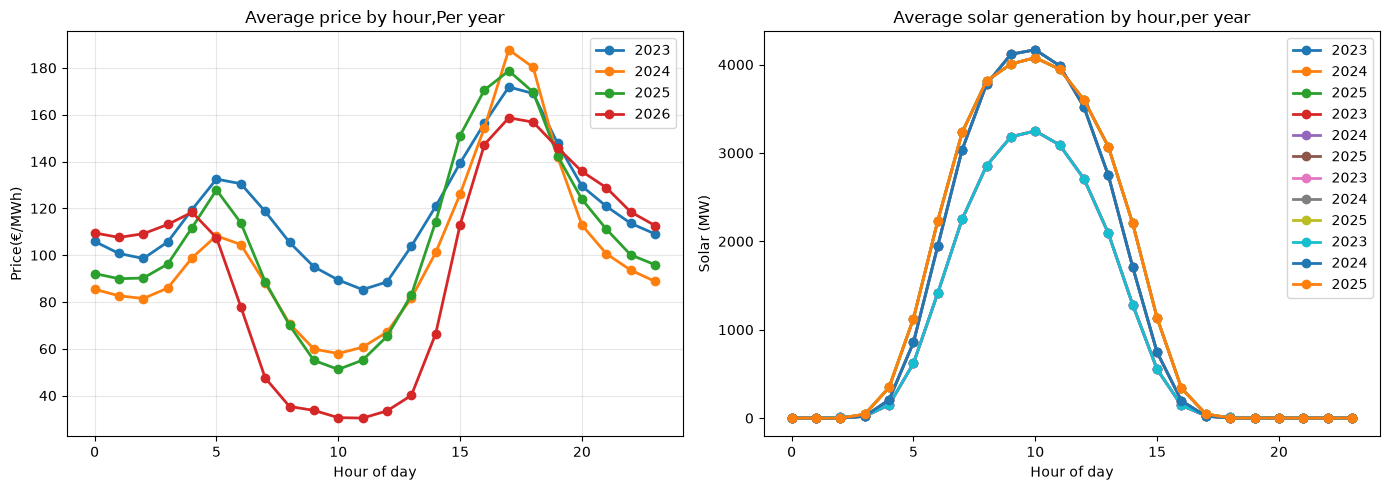

In [14]:
plt.close("all")


recent=df[df["year"]>=2023]
pivot_price=recent.pivot_table(index="hour",columns="year",values="price",aggfunc="mean")
pivot_solar=recent.pivot_table(index="hour",columns="year",values="solar",aggfunc="mean")

fig,axes=plt.subplots(1,2,figsize=(14,5),sharex=True)

for year in pivot_price.columns:
    axes[0].plot(pivot_price.index,pivot_price[year],marker="o",label=year,linewidth=2)
    axes[0].set_title("Average price by hour,Per year")
    axes[0].set_xlabel("Hour of day")
    axes[0].set_ylabel("Price(€/MWh)")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    for year in pivot_solar.columns:
        axes[1].plot(pivot_solar.index,pivot_solar[year],marker="o",label=year,linewidth=2)
    axes[1].set_title("Average solar generation by hour,per year")
    axes[1].set_xlabel("Hour of day")    
    axes[1].set_ylabel("Solar (MW)")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("../plots/duck_curve_by_year.png",dpi=150)
    plt.show

In [16]:
print("solar pivot columns:", pivot_solar.columns.tolist())
print("lines on right axes:", len(axes[1].get_lines()))
print("labels:", [l.get_label() for l in axes[1].get_lines()])
print("price pivot columns:", pivot_price.columns.tolist())


solar pivot columns: [2023, 2024, 2025]
lines on right axes: 12
labels: ['2023', '2024', '2025', '2023', '2024', '2025', '2023', '2024', '2025', '2023', '2024', '2025']
price pivot columns: [2023, 2024, 2025, 2026]
